# Experiment 4 — Effect of Activation Function

This experiment investigates the effect of changing the activation function used in the hidden layers of the neural network.

The baseline model uses the ReLU activation function. In this experiment, ReLU is replaced with Tanh while keeping the network architecture, features, data split, preprocessing, optimizer, and training procedure unchanged.

The purpose is to determine whether the choice of activation function affects the model's predictive performance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Understanding the raw Data**

In [ ]:
df.shape #Dataset has 891 rows and 12 columns

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
missing_stats = pd.concat(
    [df.isna().sum(), df.isna().mean() * 100],
    axis=1,
    keys=['Missing Count', 'Missing Percentage']
)

missing_stats

,Missing Count,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [ ]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [ ]:
df['Embarked'].value_counts(dropna=False)

,count
Embarked,
S,644
C,168
Q,77
NaN,2


**Important insights**:
1) ~38.4% survived
2) Age has 177 missing values
3) in Fare : mean=32.2 and median=14.45 -> mean is significantly higher than median, indicates that significantly high value fares exist. Worth investigating outliers
4) Cabin column has 77% missing values.

# Exploratory Data Analysis

In [ ]:
df.groupby('Sex')['Survived'].mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


In [ ]:
df.groupby('Pclass')['Survived'].mean()*100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


In [ ]:
df.groupby('Embarked')['Survived'].mean()*100

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.695652


**Sex and Pclass seem to be strongly associated with Survival**

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

In [ ]:
df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

,Survived
AgeGroup,
Child,57.971014
Teen,42.857143
Young Adult,35.555556
Adult,42.323651
Senior,34.375000


In [ ]:
df.groupby('AgeGroup', observed=True)['Survived'].agg(['count', 'mean'])

,count,mean
AgeGroup,,
Child,69,0.579710
Teen,70,0.428571
Young Adult,270,0.355556
Adult,241,0.423237
Senior,64,0.343750


In [ ]:
df.groupby('SibSp')['Survived'].agg(['count', 'mean'])

,count,mean
SibSp,,
0,608,0.345395
1,209,0.535885
2,28,0.464286
3,16,0.250000
4,18,0.166667
5,5,0.000000
8,7,0.000000


In [ ]:
df.groupby('Parch')['Survived'].agg(['count', 'mean'])

,count,mean
Parch,,
0,678,0.343658
1,118,0.550847
2,80,0.500000
3,5,0.600000
4,4,0.000000
5,5,0.200000
6,1,0.000000


* **Neither SibSp nor Parch show direct relationship with survial**
* **Small values of Parch and SibSp have high survival. But cannot be concluded directly**



In [ ]:
df.groupby('Survived')['Fare'].agg(['count', 'mean', 'median'])

,count,mean,median
Survived,,,
0,549,22.117887,10.5
1,342,48.395408,26.0


**This shows: Passengers who survivd had higher fare than passengers who did not survive**

In [ ]:
df.groupby('Ticket')['PassengerId'].transform('count').value_counts().sort_index()


,count
PassengerId,
1,547
2,188
3,63
4,44
5,10
6,18
7,21


In [ ]:
ticket_group_size = df.groupby('Ticket')['PassengerId'].transform('count')

In [ ]:
pd.DataFrame({
    'TicketGroupSize': ticket_group_size,
    'Survived': df['Survived']
}).groupby('TicketGroupSize')['Survived'].agg(['count', 'mean'])

,count,mean
TicketGroupSize,,
1,547,0.297989
2,188,0.574468
3,63,0.698413
4,44,0.500000
5,10,0.000000
6,18,0.000000
7,21,0.238095


In [ ]:
df['Ticket'].str.extract(r'^([A-Za-z./]+)')[0].value_counts()

,count
0,
PC,60
C.A.,27
A/,23
STON/O,18
W./C.,9
SOTON/O.Q.,8
CA.,8
SOTON/OQ,7
CA,6


1.  **Prefix of Tickets -> Incosistent(not meaningful)**
2.   **TicketGroupSize->Meaningful**

In [ ]:
df['Name'].str.extract(r',\s*([^.]*)\.')[0].value_counts()

,count
0,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
df.groupby(
    df['Name'].str.extract(r',\s*([^.]*)\.')[0]
)['Survived'].agg(['count', 'mean'])

,count,mean
0,,
Capt,1,0.000000
Col,2,0.500000
Don,1,0.000000
Dr,7,0.428571
Jonkheer,1,0.000000
Lady,1,1.000000
Major,2,0.500000
Master,40,0.575000
Miss,182,0.697802


**Titles look important**

In [ ]:
df['CabinKnown'] = df['Cabin'].notna().astype(int)

In [ ]:
df.groupby('Survived')['CabinKnown'].mean() * 100

,CabinKnown
Survived,
0,12.386157
1,39.766082


**Cabin column does not have any direct meaning. But CabinKnown column has potential.**

In [ ]:
df['Deck'] = df['Cabin'].str[0]
df.groupby('Deck')['Survived'].agg(['count', 'mean'])

,count,mean
Deck,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000
T,1,0.000000


In [ ]:
df.groupby(['Pclass', 'Sex'])['Survived'].agg(['count', 'mean'])


count      mean
Pclass Sex                    
1      female     94  0.968085
       male      122  0.368852
2      female     76  0.921053
       male      108  0.157407
3      female    144  0.500000
       male      347  0.135447

# Visulaization


**1) Plot 1: Sex vs Survival**

<Axes: title={'center': 'Survival Rate by Sex'}, xlabel='Sex', ylabel='Survival Rate (%)'>

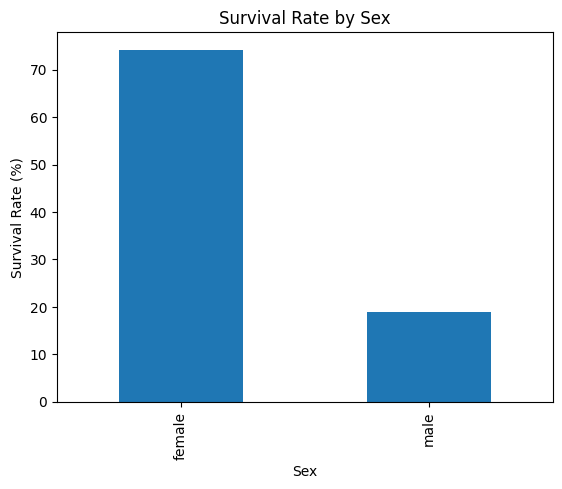

In [ ]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

survival_by_sex.plot(
    kind='bar',
    xlabel='Sex',
    ylabel='Survival Rate (%)',
    title='Survival Rate by Sex'
)

**Plot 2: Passenger Class vs Survival Rate**

<Axes: title={'center': 'Survival Rate by Passenger Class'}, xlabel='Passenger Class', ylabel='Survival Rate (%)'>

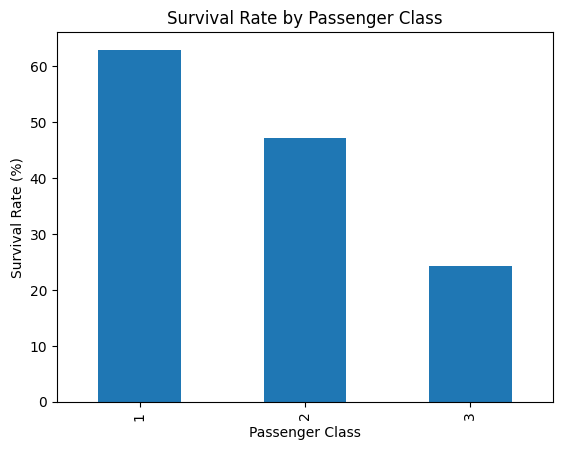

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

survival_by_class.plot(
    kind='bar',
    xlabel='Passenger Class',
    ylabel='Survival Rate (%)',
    title='Survival Rate by Passenger Class'
)

**Plot 3: Survival Rate by Sex within each Passenger Class**

<Axes: title={'center': 'Survival Rate by Sex and Passenger Class'}, xlabel='Passenger Class', ylabel='Survival Rate (%)'>

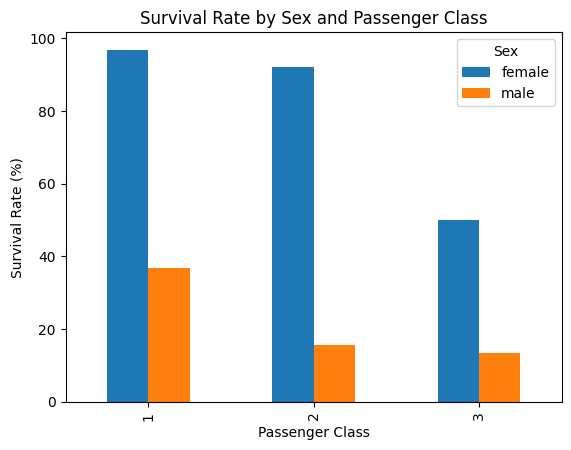

In [ ]:
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100

survival_by_class_sex.plot(
    kind='bar',
    xlabel='Passenger Class',
    ylabel='Survival Rate (%)',
    title='Survival Rate by Sex and Passenger Class'
)

**Plot 4: Fare Distribution by Survival**

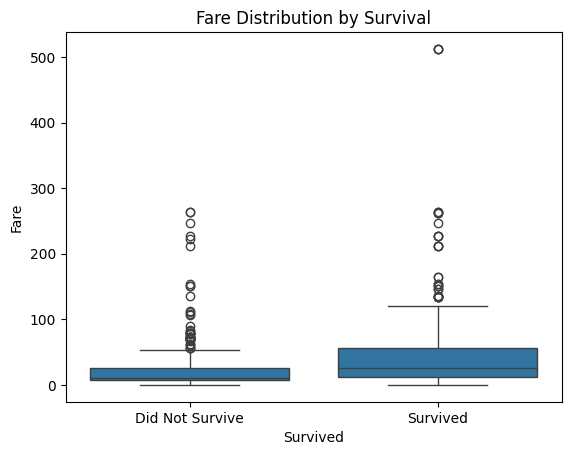

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Survived', y='Fare', data=df)

plt.xlabel('Survived')
plt.ylabel('Fare')
plt.title('Fare Distribution by Survival')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup',
       'CabinKnown', 'Deck'],
      dtype='object')

In [ ]:
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')[0]
df['TicketGroupSize'] = df.groupby('Ticket')['PassengerId'].transform('count')

In [ ]:
df = df.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin',
    'AgeGroup',
    'Deck'
])

In [ ]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'CabinKnown', 'Title', 'TicketGroupSize'],
      dtype='object')

### Feature Selection

The following features were selected based on their relevance to passenger survival and the insights obtained during EDA:

- **Pclass:** Passenger class showed a strong relationship with survival, with first class passengers having  higher survival rate than third class passenges.

- **Sex:** Sex showed one of the strongest relationships with survival. Female passengers had a considerably higher observed survival rate than male passengers.

- **Age:** Age can capture differences in survival across age groups, particularly the higher observed survival rate among children. Missing values will be handled during preprocessing.

- **SibSp:** Represents the number of siblings or spouses aboard. EDA showed differences in survival rates across different values, so it is retained as a potential predictor.

- **Parch:** Represents the number of parents or children aboard. It showed some variation in survival rates and may provide information about family/travel circumstances.

- **Fare:** Survivors had substantially higher mean and median fares than non-survivors, indicating that Fare contains potentially useful predictive information.

- **Embarked:** Survival rates differed across embarkation ports, so this feature is retained as a potential predictor. It contains only a small number of missing values.

- **Title:** Extracted from `Name` because the raw name is almost unique for every passenger. Titles such as Mr, Mrs, Miss, and Master showed substantial differences in survival rates and provide more meaningful categorical information.

- **TicketGroupSize:** Derived from the number of passengers sharing the same ticket. It showed differences in survival rates and may capture information about whether passengers were travelling as part of a group.

### Features Removed

- **PassengerId:** Identifier with no meaningful passenger characteristics.
- **Name:** Raw names are almost unique; useful information was extracted as `Title`.
- **Ticket:** High cardinality categorical feature; useful information was extracted as `TicketGroupSize`.
- **Cabin:** Approximately 77% of values are missing, and the raw cabin number is not directly meaningful for the model.
- **AgeGroup:** Created only for EDA and not retained as a model feature.
- **Deck:** Investigated during EDA but not included in the initial feature set because cabin information is available for only a small portion of passengers and its information may overlap with `Pclass`.

# Splitting the Data


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (623, 10) (623,)
Validation: (134, 10) (134,)
Test: (134, 10) (134,)


In [ ]:
print("\nSurvival distribution:")

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))


Survival distribution:

Train:
Survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64

Validation:
Survived
0    0.61194
1    0.38806
Name: proportion, dtype: float64

Test:
Survived
0    0.619403
1    0.380597
Name: proportion, dtype: float64


# **Preprocessing**

# Handling Missing Values

In [ ]:
age_group_stats = (
    X_train
    .groupby(['Sex', 'Title'])['Age']
    .agg(['count', 'median'])
    .sort_values('count')
)

age_group_stats

count  median
Sex    Title                  
female Dr            1    49.0
       Lady          1    48.0
male   Don           1    40.0
       Jonkheer      1    38.0
       Major         1    52.0
       Sir           1    49.0
       Col           2    58.0
female Mlle          2    24.0
male   Dr            4    41.0
       Rev           5    51.0
       Master       23     3.0
female Mrs          83    35.0
       Miss        100    21.0
male   Mr          279    30.0



1.   **Major Groups(Mr, Miss, Mrs, Master) look good enough to use their own medians to fill missing values**
2.  **For Minor groups, using their medians to fill missing data is unreliable.**
3. **So, we fill their missing values with Sex median for the titles with frequency<5**
4. **If sex median is not available, then impute them with median of overall training data**





In [ ]:
# Median Age by Sex — calculated only from training data
sex_age_medians = X_train.groupby('Sex')['Age'].median()

# Overall training median — final fallback
overall_age_median = X_train['Age'].median()

print("Sex-wise medians:")
print(sex_age_medians)

print("\nOverall training median:")
print(overall_age_median)

Sex-wise medians:
Sex
female    28.0
male      30.0
Name: Age, dtype: float64

Overall training median:
29.0


In [ ]:
age_group_stats = (
    X_train
    .groupby(['Sex', 'Title'])['Age']
    .agg(['count', 'median'])
)

reliable_age_medians = age_group_stats[
    age_group_stats['count'] >= 10
]['median']

reliable_age_medians

Sex     Title 
female  Miss      21.0
        Mrs       35.0
male    Master     3.0
        Mr        30.0
Name: median, dtype: float64

In [ ]:
def impute_age(data):
    data = data.copy()

    for idx in data.index:
        if pd.isna(data.loc[idx, 'Age']):

            key = (data.loc[idx, 'Sex'], data.loc[idx, 'Title'])

            if key in reliable_age_medians.index:
                data.loc[idx, 'Age'] = reliable_age_medians.loc[key]

            elif data.loc[idx, 'Sex'] in sex_age_medians.index:
                data.loc[idx, 'Age'] = sex_age_medians.loc[data.loc[idx, 'Sex']]

            else:
                data.loc[idx, 'Age'] = overall_age_median

    return data

In [ ]:
X_train = impute_age(X_train)
X_val = impute_age(X_val)
X_test = impute_age(X_test)

In [ ]:
print("Missing Age:")
print("Train:", X_train['Age'].isna().sum())
print("Validation:", X_val['Age'].isna().sum())
print("Test:", X_test['Age'].isna().sum())

Missing Age:
Train: 0
Validation: 0
Test: 0


**Embarked has only 2 missing value. Since it is Categorical, imputing it with mode makes sense.**

In [ ]:
embarked_mode = X_train['Embarked'].mode()[0]

print("Training Embarked mode:", embarked_mode)

Training Embarked mode: S


In [ ]:
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_val['Embarked'] = X_val['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

In [ ]:
print("Missing Embarked:")
print("Train:", X_train['Embarked'].isna().sum())
print("Validation:", X_val['Embarked'].isna().sum())
print("Test:", X_test['Embarked'].isna().sum())

Missing Embarked:
Train: 0
Validation: 0
Test: 0


In [ ]:
print("Sex:")
print(X_train['Sex'].unique())

print("\nEmbarked:")
print(X_train['Embarked'].unique())

print("\nTitle:")
print(X_train['Title'].value_counts())

Sex:
['male' 'female']

Embarked:
['S' 'Q' 'C']

Title:
Title
Mr          364
Miss        122
Mrs          91
Master       26
Dr            6
Rev           5
Col           2
Mlle          2
Major         1
Lady          1
Jonkheer      1
Don           1
Sir           1
Name: count, dtype: int64


In [ ]:
#Keeping all the titles with low frequency in 'Rare' category.
major_titles = ['Mr', 'Miss', 'Mrs', 'Master']

for data in [X_train, X_val, X_test]:
    data['Title'] = data['Title'].where(
        data['Title'].isin(major_titles),
        'Rare'
    )

In [ ]:
X_train['Title'].value_counts()

,count
Title,
Mr,364
Miss,122
Mrs,91
Master,26
Rare,20


**Encoding**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_cols = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'TicketGroupSize'
]

categorical_cols = [
    'Sex',
    'Embarked',
    'Title',
    'CabinKnown'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(
            drop='if_binary',
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_cols)
    ],
    remainder='drop'
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Train shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (623, 16)
Validation shape: (134, 16)
Test shape: (134, 16)


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)
print("Total features:", len(feature_names))

['num__Pclass' 'num__Age' 'num__SibSp' 'num__Parch' 'num__Fare'
 'num__TicketGroupSize' 'cat__Sex_male' 'cat__Embarked_C'
 'cat__Embarked_Q' 'cat__Embarked_S' 'cat__Title_Master' 'cat__Title_Miss'
 'cat__Title_Mr' 'cat__Title_Mrs' 'cat__Title_Rare' 'cat__CabinKnown_1']
Total features: 16


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
class TitanicNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.Tanh(),

            nn.Linear(32, 16),
            nn.Tanh(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model = TitanicNN(X_train_processed.shape[1])

print(model)

TitanicNN(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([32, 16])
y batch shape: torch.Size([32, 1])


In [ ]:
num_epochs = 100
patience = 10

### Training

The network using the Tanh activation function is trained using the same training procedure as the baseline model. Keeping the remaining training settings unchanged ensures that any difference in performance can primarily be attributed to the change in activation function.
### Validation Evaluation

The model is evaluated on the validation set using accuracy, precision, recall, and F1-score. The same evaluation procedure as the baseline model is used to allow a direct comparison between the ReLU and Tanh activation functions.

In [ ]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # -------------------------
    # Early stopping
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        patience_counter = 0

        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

    # Print progress
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch [1/100] Train Loss: 0.6529 Val Loss: 0.6276
Epoch [2/100] Train Loss: 0.6015 Val Loss: 0.5832
Epoch [3/100] Train Loss: 0.5572 Val Loss: 0.5401
Epoch [4/100] Train Loss: 0.5162 Val Loss: 0.4981
Epoch [5/100] Train Loss: 0.4727 Val Loss: 0.4635
Epoch [6/100] Train Loss: 0.4429 Val Loss: 0.4355
Epoch [7/100] Train Loss: 0.4242 Val Loss: 0.4187
Epoch [8/100] Train Loss: 0.4126 Val Loss: 0.4099
Epoch [9/100] Train Loss: 0.4079 Val Loss: 0.4041
Epoch [10/100] Train Loss: 0.4075 Val Loss: 0.4020
Epoch [11/100] Train Loss: 0.4089 Val Loss: 0.4019
Epoch [12/100] Train Loss: 0.4121 Val Loss: 0.4040
Epoch [13/100] Train Loss: 0.4208 Val Loss: 0.4012
Epoch [14/100] Train Loss: 0.4079 Val Loss: 0.4013
Epoch [15/100] Train Loss: 0.4001 Val Loss: 0.4002
Epoch [16/100] Train Loss: 0.4130 Val Loss: 0.3996
Epoch [17/100] Train Loss: 0.3983 Val Loss: 0.4005
Epoch [18/100] Train Loss: 0.4015 Val Loss: 0.3979
Epoch [19/100] Train Loss: 0.3954 Val Loss: 0.3968
Epoch [20/100] Train Loss: 0.3962 Val Lo

In [ ]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

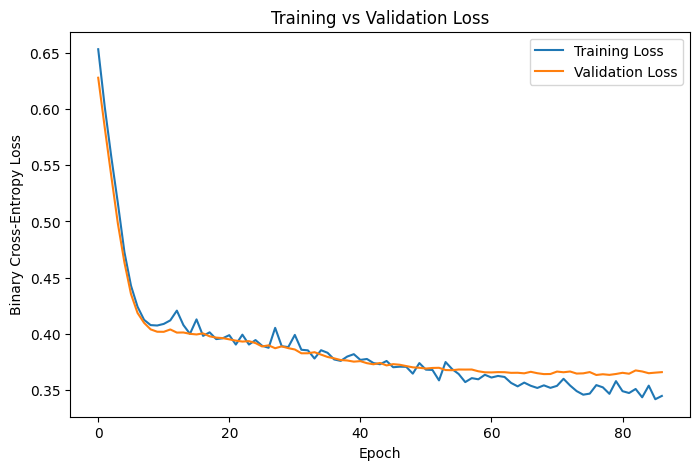

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

val_probabilities = []
val_actual = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:

        probabilities = model(X_batch)

        val_probabilities.extend(
            probabilities.squeeze().numpy()
        )

        val_actual.extend(
            y_batch.squeeze().numpy()
        )

In [ ]:
val_predictions = [
    1 if p >= 0.5 else 0
    for p in val_probabilities
]

In [ ]:
val_accuracy = accuracy_score(
    val_actual,
    val_predictions
)

val_precision = precision_score(
    val_actual,
    val_predictions
)

val_recall = recall_score(
    val_actual,
    val_predictions
)

val_f1 = f1_score(
    val_actual,
    val_predictions
)

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

Accuracy : 0.8358
Precision: 0.8261
Recall   : 0.7308
F1-score : 0.7755


### Result and Conclusion

The model using the Tanh activation function achieved:

- **Accuracy:** 83.58%
- **Precision:** 82.61%
- **Recall:** 73.08%
- **F1-score:** 77.55%

Compared with the ReLU baseline, the Tanh activation function resulted in lower validation performance, particularly in recall and F1-score.

Therefore, ReLU was retained as the activation function for the subsequent experiments.

In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        val_actual,
        val_predictions,
        target_names=['Did not survive', 'Survived']
    )
)


Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.84      0.90      0.87        82
       Survived       0.83      0.73      0.78        52

       accuracy                           0.84       134
      macro avg       0.83      0.82      0.82       134
   weighted avg       0.84      0.84      0.83       134



In [ ]:
cm = confusion_matrix(
    val_actual,
    val_predictions
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[74  8]
 [14 38]]


### Conclusion

Replacing ReLU with Tanh resulted in lower validation performance, particularly in recall and F1-score. Therefore, ReLU was retained as the activation function for the subsequent experiments.